In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib Inline
%config InlineBackend.figure_format="svg"

## Lab tasks
### The Validation Set Approach

We explore the use of the validation set approach in order to estimate the
test error rates that result from fitting various linear models on the Auto
data set.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
auto = pd.read_csv("data/Auto.csv")
auto["horsepower"] = pd.to_numeric(auto["horsepower"].replace("?", np.nan))
auto = auto.dropna().reset_index(drop=True)

In [6]:
X = auto[["horsepower"]]
Y = auto[["mpg"]]

def evaluate_polynomials(X, y, random_state):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, random_state=random_state)
    
    mses = {}
    
    for degree in [1, 2, 3]:
        if degree == 1:
            model = LinearRegression()
            model.fit(X_train, y_train)
            preds = model.predict(X_val)
        else:
            poly = PolynomialFeatures(degree=degree, include_bias=False)
            X_train_poly = poly.fit_transform(X_train)
            X_val_poly = poly.transform(X_val)
            
            model = LinearRegression()
            model.fit(X_train_poly, y_train)
            preds = model.predict(X_val_poly)
            
        mses[degree] = mean_squared_error(y_val, preds)
        
    return mses

In [14]:
print("=== Experiment 1 ===")
exp_1_results = evaluate_polynomials(X=X, y=Y, random_state=1)
print("In this case we have chosen random seed = 1. \nThe information below showes the result of fitting the Linear Regression "
"using different values of polynoms\n")
for pol, mse in exp_1_results.items():
    print(f"Linear regression with polynom {pol} get MSE: {mse}")

=== Experiment 1 ===
In this case we have chosen random seed = 1. 
The information below showes the result of fitting the Linear Regression using different values of polynoms

Linear regression with polynom 1 get MSE: 24.80212062059356
Linear regression with polynom 2 get MSE: 18.848292603275663
Linear regression with polynom 3 get MSE: 18.805111358605235


In [18]:
print("=== Experiment 2 ===")
exp_1_results = evaluate_polynomials(X=X, y=Y, random_state=10)
print("In this case we have chosen random seed = 10. \nThe information below showes the result of fitting the Linear Regression "
"using different values of polynoms\n")
for pol, mse in exp_1_results.items():
    print(f"Linear regression with polynom {pol} get MSE: {mse}")

=== Experiment 2 ===
In this case we have chosen random seed = 10. 
The information below showes the result of fitting the Linear Regression using different values of polynoms

Linear regression with polynom 1 get MSE: 23.06058834250622
Linear regression with polynom 2 get MSE: 19.717794109923414
Linear regression with polynom 3 get MSE: 19.708416156919125


As we can see, a more flexible method turned out to be a better choice for predicting mpg based on horsepower. The quadratic and cubic models (degrees 2 and 3) showed better results (around 19.7) compared to simple linear regression (23.06). The flexibility of the higher-degree models is sufficient to capture the underlying patterns without overfitting, even though we used only a single feature

The main conclusion is that the Validation Set approach heavily depends on which observations are selected for the validation set. When the random seed was set to 1, the results were 24.8, 18.8, and 18.8. Changing the random state to 10 caused the results to change significantly. While this approach provides a good opportunity to test our model using a holdout sample, it still suffers from high variance. The fact that changing the random state alters the results so much clearly demonstrates this instability

### Leave-One-Out Cross-Validation

In [19]:
from sklearn.model_selection import LeaveOneOut, cross_val_score

In [23]:
X = auto[["horsepower"]]
y = auto[["mpg"]]

loo = LeaveOneOut()
cv_errors = []

for i in range(1, 6):
    if i == 1:
        model = LinearRegression()
        scores = cross_val_score(model, X, y, cv=loo, scoring="neg_mean_squared_error")
    else:
        poly = PolynomialFeatures(degree=i, include_bias=False)
        X_poly = poly.fit_transform(X)
        
        model = LinearRegression()
        scores = cross_val_score(model, X_poly, y, cv=loo, scoring="neg_mean_squared_error")
    
    mean_mse = -np.mean(scores)
    cv_errors.append(mean_mse)
    print(f"polynomials of degree {i} | LOOCV MSE: {mean_mse:.4f}")

print("\nThe result vector:")
print(cv_errors)

polynomials of degree 1 | LOOCV MSE: 24.2315
polynomials of degree 2 | LOOCV MSE: 19.2482
polynomials of degree 3 | LOOCV MSE: 19.3350
polynomials of degree 4 | LOOCV MSE: 19.4244
polynomials of degree 5 | LOOCV MSE: 19.0332

The result vector:
[np.float64(24.23151351792922), np.float64(19.248213124489684), np.float64(19.334984064029346), np.float64(19.424430310350626), np.float64(19.0332122147925)]


Once again, the more flexible model won the competition. Now we can be sure that the relationship between mpg and horsepower is quadratic. The evidence for this conclusion is the dramatic decrease in MSE (by 5 units).

LOOCV allows us to perform quite accurate testing of our model's predictions without relying on a single validation split. This time, the evaluation does not depend on random sampling because we use $n-1$ observations for training each time. If we restart the fitting process, we will not observe any changes. Yet, LOOCV still has high variance because it uses almost the same training set each time,therefore, there is a high correlation between the estimated models, hence increasing the overall variance

### Leave-One-Out Cross-Validation

In [25]:
from sklearn.model_selection import KFold

In [27]:
X = auto[["horsepower"]]
y = auto[["mpg"]]

kf = KFold(n_splits=10, random_state=17, shuffle=True)
cv_errors_10 = []

for i in range(1, 11):
    if i == 1:
        model = LinearRegression()
        scores = cross_val_score(model, X, y, cv=kf, scoring="neg_mean_squared_error")
    else:
        poly = PolynomialFeatures(degree=i, include_bias=False)
        X_poly = poly.fit_transform(X)
        
        model = LinearRegression()
        scores = cross_val_score(model, X_poly, y, cv=kf, scoring="neg_mean_squared_error")
        
    mean_mse = -np.mean(scores)
    cv_errors_10.append(mean_mse)
    print(f"polynomials of degree {i} | 10-fold MSE: {mean_mse:.4f}")

polynomials of degree 1 | 10-fold MSE: 24.1823
polynomials of degree 2 | 10-fold MSE: 19.1376
polynomials of degree 3 | 10-fold MSE: 19.1552
polynomials of degree 4 | 10-fold MSE: 19.2502
polynomials of degree 5 | 10-fold MSE: 18.8971
polynomials of degree 6 | 10-fold MSE: 19.0255
polynomials of degree 7 | 10-fold MSE: 18.9791
polynomials of degree 8 | 10-fold MSE: 18.8582
polynomials of degree 9 | 10-fold MSE: 19.0099
polynomials of degree 10 | 10-fold MSE: 19.7377


This case clearly demonstrates the fact that an increase in model flexibility does not always lead to better results. The polynomial of degree 2 significantly decreased the test error, but higher-order polynomials did not make a big difference and hovered around the same level.

The main conclusion is that the k-fold approach takes less time for fitting due to the smaller number of training iterations. Also, this approach manages to find a good balance between variance and bias. It uses different groups of observations and, at the same time, does not introduce high correlation between the models

### The Bootstrap

In [28]:
portfolio = pd.read_csv("data/Portfolio.csv")

In [35]:
def alpha_fn(data, index):
    df = data.loc[index]
    X = df["X"]
    Y = df["Y"]
    
    cov_matrix = np.cov(X, Y)
    var_X = cov_matrix[0, 0]
    var_Y = cov_matrix[1, 1]
    cov_XY = cov_matrix[0, 1]
    
    return (var_Y - cov_XY) / (var_X + var_Y - 2 * cov_XY)

In [33]:
print("Origin Alpha:", alpha_fn(portfolio, portfolio.index))

Origin Alpha: 0.5758320745928298


In [34]:
bootstrap_1 = np.random.choice(portfolio.index, size=100, replace=True)
print("1 Bootstrap Alpha:", alpha_fn(portfolio, bootstrap_1))

1 Bootstrap Alpha: 0.618716274297488


The results for these two samples are quite different. In order to obtain a reliable bootstrap estimate (or standard error), we need to generate a large number of bootstrap replicates (e.g., $B = 1000$)

In [37]:
np.random.seed(1)

B = 1000
bootstrap_alphas = []

for b in range(B):
    current_b = np.random.choice(portfolio.index, replace=True, size=100)
    
    alpha = alpha_fn(portfolio, current_b)
    bootstrap_alphas.append(alpha)

bootstrap_alphas = np.array(bootstrap_alphas)
se_alpha = np.std(bootstrap_alphas, ddof=1)
mean_alpha = np.mean(bootstrap_alphas)

print(f"Mean alpha is {mean_alpha}")
print(f"Standard Error alpha is {se_alpha}")
print(f"Mean alpha is {mean_alpha}")

Mean alpha is 0.5784905227103104
Standard Error alpha is 0.09296141702441607
Mean alpha is 0.5784905227103104


Based on these calculations, we can draw the following conclusions:
- The results obtained via the bootstrap method are remarkably close to the original estimate
- The Standard Error is quite low (0.0930), which implies that our alpha estimate is stable and trustworthy; this metric is unlikely to fluctuate significantly across different samples
- The bootstrap mean alpha is almost identical to the original value

The bootstrap approach successfully produced an accurate estimate and demonstrated that this allocation ratio can be reliably used for investment decisions 

In [41]:
def boot_fn(data, index):
    df = data.loc[index]
    X_boot = df[["horsepower"]]
    y_boot = df["mpg"]
    
    model = LinearRegression()
    model.fit(X_boot, y_boot)
    
    return model.intercept_, model.coef_[0]


b0_orig, b1_orig = boot_fn(auto, auto.index)
print(f"Original Coefficients:\nIntercept (Beta_0): {b0_orig:.4f}\nHorsepower (Beta_1): {b1_orig:.4f}\n")

beta_0 = []
beta_1 = []

for b in range(B):
    current_b = np.random.choice(auto.index, replace=True, size=auto.shape[0])
    
    intercept, coef_0 = boot_fn(auto, current_b)
    beta_0.append(intercept)
    beta_1.append(coef_0)

print("beta_0 mean:", np.mean(beta_0))
print("beta_1 mean:", np.mean(beta_1))

print("\nbeta_0 Standard Error:", np.std(beta_0, ddof=1))
print("beta_1 Standard Error:", np.std(beta_1, ddof=1))

Original Coefficients:
Intercept (Beta_0): 39.9359
Horsepower (Beta_1): -0.1578

beta_0 mean: 39.89422508142119
beta_1 mean: -0.15747040471628057

beta_0 Standard Error: 0.8104833010447667
beta_1 Standard Error: 0.00689344114483501


To sum up, the mean values for the computed coefficients are noticeably close to the original weights. The standard errors are quite low, although the standard error for $\beta_1$ is much smaller

In [48]:
1 / np.pow(5,5)

np.float64(0.00032)

In [65]:
1 - (1 - 1 / 100) ** 100

0.6339676587267709

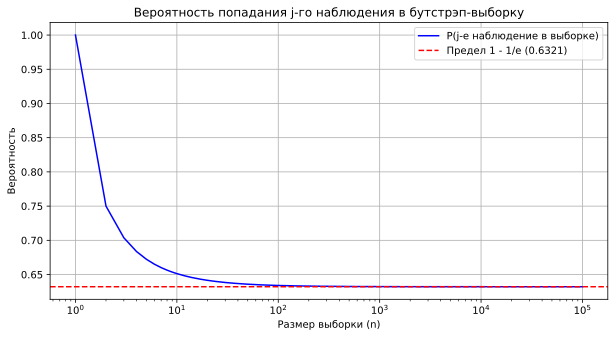

In [64]:
n_values = np.logspace(0, 5, 500, dtype=int) 

# Считаем вероятности по нашей формуле
probabilities = 1 - (1 - 1 / n_values) ** n_values

# Строим график
plt.figure(figsize=(10, 5))
plt.plot(n_values, probabilities, label='P(j-е наблюдение в выборке)', color='blue')
plt.axhline(y=1 - 1/np.e, color='red', linestyle='--', label=f'Предел 1 - 1/e ({1 - 1/np.e:.4f})')
plt.xscale('log') # Используем логарифмическую шкалу для наглядности
plt.xlabel('Размер выборки (n)')
plt.ylabel('Вероятность')
plt.title('Вероятность попадания j-го наблюдения в бутстрэп-выборку')
plt.grid(True)
plt.legend()
plt.show()

## Block Applied

### 5. TASK

In Chapter 4, we used logistic regression to predict the probability of
default using income and balance on the Default data set. We will
now estimate the test error of this logistic regression model using the
validation set approach. Do not forget to set a random seed before
beginning your analysis.

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

(a) Fit a logistic regression model that uses income and balance to
predict default.

(b) Using the validation set approach, estimate the test error of this
model. In order to do this, you must perform the following steps:
- Split the sample set into a training set and a validation set.
- Fit a multiple logistic regression model using only the training observations.
- Obtain a prediction of default status for each individual in the validation set by computing the posterior probability of default for that individual, and classifying the individual to the default category if the posterior probability is greater than 0.5.
- Compute the validation set error, which is the fraction of
the observations in the validation set that are misclassified.

In [82]:
default = pd.read_csv("data/Default.csv")
default["default_bi"] = default["default"].map({"Yes": 1, "No": 0})

X = default[["balance", "income"]]
y = default["default_bi"]


def calc_validation_error(seed, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=seed)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_valid_scaled = scaler.transform(X_val)

    lr = LogisticRegression(random_state=seed)
    lr.fit(X_train_scaled, y_train)
    y_preds = lr.predict(X_valid_scaled)

    validation_error = accuracy_score(y_val, y_preds)

    return validation_error

validation_error = calc_validation_error(seed=42, X=X, y=y)
print("Validation Error Rate is", 1 - validation_error)

Validation Error Rate is 0.027599999999999958


(c) Repeat the process in (b) three times, using three different splits
of the observations into a training set and a validation set. Comment on the results obtained.

In [83]:
randoms_states = [60, 72, 10]

for state in randoms_states:

    validation_error = calc_validation_error(seed=state, X=X, y=y)
    print("Random_state =", state)
    print("Validation Error Rate is", 1 - validation_error)

Random_state = 60
Validation Error Rate is 0.026000000000000023
Random_state = 72
Validation Error Rate is 0.023599999999999954
Random_state = 10
Validation Error Rate is 0.030000000000000027


Based on the calculations above, we can draw the following conclusion: the final validation error rate depends heavily on the specific validation split. For instance, with random_state=60 the error is 0.0260, with random_state=72 it drops to 0.0236, and with random_state=10 it increases to 0.0300

(d) Now consider a logistic regression model that predicts the probability of default using income, balance, and a dummy variable
for student. Estimate the test error for this model using the validation set approach. Comment on whether or not including a
dummy variable for student leads to a reduction in the test error
rate.

In [84]:
default["student_new"] = default["student"].map({"Yes": 1, "No": 0})

X = default[["income", "balance", "student_new"]]
y = default["default_bi"]

validation_error = calc_validation_error(seed=42, X=X, y=y)
print("Random_state =", 42)
print("Validation Error Rate is", 1 - validation_error)

Random_state = 42
Validation Error Rate is 0.027599999999999958


The addition of the dummy variable for students did not change the validation error rate. The value remained identical. We should also note that this comparison was made using the exact same random_state

### 6. TASK

We continue to consider the use of a logistic regression model to
predict the probability of default using income and balance on the
Default data set. In particular, we will now compute estimates for
the standard errors of the income and balance logistic regression coefficients in two different ways: (1) using the bootstrap, and (2) using
the standard formula for computing the standard errors in the glm()
function. Do not forget to set a random seed before beginning your
analysis

(a) Using the summary() and glm() functions, determine the estimated standard errors for the coefficients associated with income
and balance in a multiple logistic regression model that uses
both predictors.

In [86]:
import statsmodels.formula.api as smf

In [88]:
model = smf.logit("default_bi ~ balance + income", data=default).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.078948
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:             default_bi   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9997
Method:                           MLE   Df Model:                            2
Date:                Wed, 17 Jun 2026   Pseudo R-squ.:                  0.4594
Time:                        18:34:44   Log-Likelihood:                -789.48
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                4.541e-292
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -11.5405      0.435    -26.544      0.000     -12.393     -10.688
balance        0.0056      0

The coefficients:
- balance 0.0056
- income 2.081e-05

Both variable balance and income are statisticaly significant (p-value less than 0.000)

The Standard Error for them:
- balance 0.000
- income 4.99e-06

(b) Write a function, boot.fn(), that takes as input the Default data
set as well as an index of the observations, and that outputs
the coefficient estimates for income and balance in the multiple
logistic regression model.

(c) Use the boot() function together with your boot.fn() function to
estimate the standard errors of the logistic regression coefficients
for income and balance.

(d) Comment on the estimated standard errors obtained using the
glm() function and using your bootstrap function.

In [120]:
def boot_fn(X, y, index):
    X_boot = X.iloc[index]
    y_boot = y.iloc[index]
    lr = LogisticRegression(penalty=None)
    lr.fit(X_boot, y_boot)
    intercept, balance_beta, income_beta = lr.intercept_[0], lr.coef_[0][0], lr.coef_[0][1]
    
    return [intercept, balance_beta, income_beta]


rates = []
B = 1000
X = default[["balance", "income"]]
y = default["default_bi"]

for b in range(B):
    bootstrap = np.random.choice(default.shape[0], size=default.shape[0], replace=True)

    current_rates = boot_fn(X=X, y=y, index=bootstrap)
    rates.append(current_rates)

final_rates = np.array(rates).std(axis=0)

print(f"The Standard Deviation for intercept is {final_rates[0]}")
print(f"The Standard Deviation for balance is {final_rates[1]}")
print(f"The Standard Deviation for income is {final_rates[2]}")

The Standard Deviation for intercept is 0.41808168332885115
The Standard Deviation for balance is 0.0002202360125433827
The Standard Deviation for income is 4.6481992881473445e-06


In [122]:
original_coefs = [model.params[0], model.params[1], model.params[2]] # коэффициенты из statsmodels
bootstrap_means = np.array(rates).mean(axis=0)
bias = bootstrap_means - original_coefs
print("Bootstrap Bias:", bias)

Bootstrap Bias: [-1.68264020e-02  9.82319803e-06 -7.16516151e-08]


C:\Users\ilyas\AppData\Local\Temp\ipykernel_2044\2372391383.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  original_coefs = [model.params[0], model.params[1], model.params[2]] # коэффициенты из statsmodels


Having finished the experiment with bootstrap we can draw the next conclusion:
- The Standard Errors for all coefficients are extremely low.
- We can trust the estimated coefficients
- They will not vary significantly if the sample changes

The difference between estimated coefficients and origin coefficients are very small

### 7. TASK

In Sections 5.3.2 and 5.3.3, we saw that the cv.glm() function can be
used in order to compute the LOOCV test error estimate. Alternatively, one could compute those quantities using just the glm() and predict.glm() functions, and a for loop. You will now take this approach in order to compute the LOOCV error for a simple logistic
regression model on the Weekly data set. Recall that in the context
of classification problems, the LOOCV error is given in (5.4).

(a) Fit a logistic regression model that predicts Direction using Lag1
and Lag2.

In [123]:
weekly = pd.read_csv("data/Weekly.csv")
weekly["Direction_bi"] = weekly["Direction"].map({"Up": 1, "Down": 0})

X = weekly[["Lag1", "Lag2"]]
y = weekly["Direction_bi"]
n = len(weekly)

lr_all = LogisticRegression(penalty=None)
lr_all.fit(X, y)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


(b) Fit a logistic regression model that predicts Direction using Lag1
and Lag2 using all but the first observation.

(c) Use the model from (b) to predict the direction of the first observation. You can do this by predicting that the first observation
will go up if P(Direction="Up"|Lag1, Lag2) > 0.5. Was this observation correctly classified?

In [139]:
X_without_first_obs = X.drop(0, axis=0)
y_without_first_obs = y.drop(0)

lr_without_first = LogisticRegression(penalty=None)
lr_without_first.fit(X_without_first_obs, y_without_first_obs)

only_first_pred = lr_without_first.predict(X.iloc[[0]])

print("First real observations is", y.iloc[0])
print("First predicted observations is", only_first_pred)
print("Prediction is equal the real observation:", only_first_pred == y.iloc[0])

First real observations is 0
First predicted observations is [1]
Prediction is equal the real observation: [False]


The model fitted on n-1 observations did not manage to correctly predict first observations. But we still should fit n-1 times more

(d) Write a for loop from i = 1 to i = n, where n is the number of
observations in the data set, that performs each of the following
steps:
- i. Fit a logistic regression model using all but the ith observation to predict Direction using Lag1 and Lag2.
- ii. Compute the posterior probability of the market moving up
for the ith observation.
- iii. Use the posterior probability for the ith observation in order to predict whether or not the market moves up.
- iv. Determine whether or not an error was made in predicting the direction for the ith observation. If an error was made, then indicate this as a 1, and otherwise indicate it as a 0.

(e) Take the average of the n numbers obtained in (d)iv in order to
obtain the LOOCV estimate for the test error. Comment on the
results.

In [140]:
errors = []

for i in range(n):

    X_train = X.drop(i, axis=0)
    y_train = y.drop(i)
    
    X_test = X.iloc[[i]]
    y_test = y.iloc[i]

    lr_loocv = LogisticRegression(penalty=None)
    lr_loocv.fit(X_train, y_train)

    current_pred = lr_loocv.predict(X_test)

    errors.append(1 if current_pred != y_test else 0)

loocv_error = np.mean(errors)
print(f"LOOCV Test Error Rate: {loocv_error}")

LOOCV Test Error Rate: 0.44995408631772266


After fitting the model using Leave-One-Out Cross-Validation (LOOCV), the test error rate is approximately 0.45. This is a fairly high value. Although LOOCV successfully minimizes bias (since each model trains on $n-1$ observations), the high error rate indicates that the predictors (Lag1, Lag2) have weak predictive power. Additionally, we must remember that LOOCV estimates tend to have high variance due to the strong correlation between the training sets.

### 8. TASK

We will now perform cross-validation on a simulated data set.

(a) Generate a simulated data set. In this data set, what is n and what is p? Write out the model
used to generate the data in equation form.

In [144]:
np.random.seed(1)
x = np.random.normal(size=100)
y = x - 2 * (x**2) + np.random.normal(size=100)

n = 100, p = 1

The equation is $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \epsilon$

(b) Create a scatterplot of X against Y . Comment on what you find.

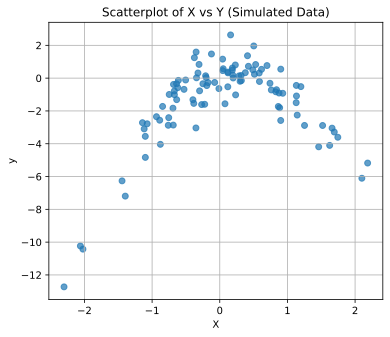

In [152]:
plt.figure(figsize=(6, 5))

plt.scatter(x, y, alpha=0.7)
plt.title("Scatterplot of X vs Y (Simulated Data)")
plt.xlabel("X")
plt.ylabel("y")

plt.grid()

plt.show()

The chart above shows the distribution of X againt Y. It can be clearly seen that chart has specific shape of inverted parabola. It means that the relationship between target and features are not linear. Here we should use more flexible model or the linear model with second degree polynomial.

(c) Set a random seed, and then compute the LOOCV errors that
result from fitting the following four models using least squares:
- i. Y = β0 + β1X + $\epsilon$
- ii. Y = β0 + β1X + β2X2 + $\epsilon$
- iii. Y = β0 + β1X + β2X2 + β3X3 + $\epsilon$
- iv. Y = β0 + β1X + β2X2 + β3X3 + β4X4 + $\epsilon$

In [153]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score

In [172]:
df = pd.DataFrame({"X": x, "Y": y})

for degree in range(1, 5):
    X_poly = np.vstack([df["X"]**i for i in range(1, degree + 1)]).T
    
    lr = LinearRegression()
    loo = LeaveOneOut()
    
    scores = cross_val_score(lr, X_poly, df["Y"], cv=loo, scoring="neg_mean_squared_error")
    
    loocv_mse = -np.mean(scores)
    print(f"Polynomial Degree {degree} - LOOCV MSE: {loocv_mse:.4f}")

Polynomial Degree 1 - LOOCV MSE: 6.2608
Polynomial Degree 2 - LOOCV MSE: 0.9143
Polynomial Degree 3 - LOOCV MSE: 0.9269
Polynomial Degree 4 - LOOCV MSE: 0.8669


As was expected the second degree polynomial reached very small MSE 0.9143, although the forth degree polynomial got the best result MSE 0.8669

(d) Repeat (c) using another random seed, and report your results.
Are your results the same as what you got in (c)? Why?

(e) Which of the models in (c) had the smallest LOOCV error? Is
this what you expected? Explain your answer.

In [175]:
np.random.seed(30)
x = np.random.normal(size=100)
y = x - 2 * (x**2) + np.random.normal(size=100)

df = pd.DataFrame({"X": x, "Y": y})

for degree in range(1, 5):
    X_poly = np.vstack([df["X"]**i for i in range(1, degree + 1)]).T
    
    lr = LinearRegression()
    loo = LeaveOneOut()
    
    scores = cross_val_score(lr, X_poly, df["Y"], cv=loo, scoring="neg_mean_squared_error")
    
    loocv_mse = -np.mean(scores)
    print(f"Polynomial Degree {degree} - LOOCV MSE: {loocv_mse:.4f}")

Polynomial Degree 1 - LOOCV MSE: 7.3073
Polynomial Degree 2 - LOOCV MSE: 0.9792
Polynomial Degree 3 - LOOCV MSE: 1.0201
Polynomial Degree 4 - LOOCV MSE: 1.0387


The LOOCV results change when we regenerate the dataset with a new random seed. Under seed=1, the 4th-degree polynomial yields the lowest MSE (0.8669), closely followed by the quadratic model (0.9143). However, under seed=30, the quadratic model performs best (0.9792), while the 4th-degree model overfits, resulting in a higher MSE (1.0387).The fact that the 4th-degree polynomial won in the first case does not mean it found a "true complex pattern"; rather, its high flexibility allowed it to accidentally fit the specific random noise ($\epsilon$) present in that particular sample. Since the true data-generating process is strictly quadratic ($Y = X - 2X^2 + \epsilon$), the 2nd-degree polynomial is the expected optimal model.Note on LOOCV: It is crucial to note that LOOCV has zero variance with respect to data splitting because its split is deterministic. The variation in results across seeds is entirely due to the variance of the underlying data-generating process itself

One more noticeable thing is at thi first time the model with higher polynomial has reached the best result although we expected the second polynomial will show the best result. It has occured due to the fact that the more flexible model has managed to see more difficult pattern and use this flexibility in order to reduce error.

(f) Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using
least squares. Do these results agree with the conclusions drawn
based on the cross-validation results?

In [177]:
import statsmodels.formula.api as smf

df["X2"] = df["X"]**2
df["X3"] = df["X"]**3
df["X4"] = df["X"]**4

model_poly4 = smf.ols("Y ~ X + X2 + X3 + X4", data=df).fit()
print(model_poly4.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.906
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     228.8
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           7.51e-48
Time:                        23:50:20   Log-Likelihood:                -137.00
No. Observations:                 100   AIC:                             284.0
Df Residuals:                      95   BIC:                             297.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1748      0.152     -1.147      0.2

If we examine the OLS summary for the 4th-degree model, only the linear ($X$) and quadratic ($X^2$) coefficients are statistically significant ($p$-value $< 0.05$). The cubic ($X^3$) and quartic ($X^4$) terms are highly insignificant. This perfectly agrees with our cross-validation conclusions: introducing higher-order terms leads to overfitting on noise rather than capturing true structural relationships.

### 9. TASK

We will now consider the Boston housing data set, from the MASS
library.

(a) Based on this data set, provide an estimate for the population
mean of medv. Call this estimate ˆμ.

(b) Provide an estimate of the standard error of ˆμ. Interpret this
result.
Hint: We can compute the standard error of the sample mean by
dividing the sample standard deviation by the square root of the
number of observations.

(c) Now estimate the standard error of ˆμ using the bootstrap. How
does this compare to your answer from (b)?

In [181]:
boston = pd.read_csv("data/Boston.csv")

medv = boston["medv"]
n = len(medv)

mu_hat = medv.mean()
print(f"(a) Estimated population mean (mu_hat): {mu_hat:.4f}")

se_formula = medv.std() / np.sqrt(n)
print(f"(b) Standard Error via formula: {se_formula:.4f}")


boot_means = []
B = 1000
np.random.seed(42)

for b in range(B):
    index_to_use = np.random.choice(boston.index, size=boston.shape[0], replace=True)
    current_bootstrap = medv[index_to_use]
    current_mean = np.mean(current_bootstrap)
    boot_means.append(current_mean)

se_boot = np.std(boot_means, ddof=1)
print(f"(c) Standard Error via Bootstrap: {se_boot:.4f}")

(a) Estimated population mean (mu_hat): 22.5328
(b) Standard Error via formula: 0.4089
(c) Standard Error via Bootstrap: 0.3971


The values for Standard Errors which were calculated through formula and Bootstrap are nearly similar (the difference is 0.01179). We have got stable estimate for the mean of medv

(d) Based on your bootstrap estimate from (c), provide a 95 % con-
fidence interval for the mean of medv. Compare it to the results
obtained using t.test(Boston$medv).
Hint: You can approximate a 95 % confidence interval using the
formula [ˆμ − 2SE(ˆμ), μˆ + 2SE(ˆμ)].

(e) Based on this data set, provide an estimate, ˆμmed, for the median
value of medv in the population.

(f) We now would like to estimate the standard error of ˆμmed. Unfortunately, there is no simple formula for computing the standard
error of the median. Instead, estimate the standard error of the
median using the bootstrap. Comment on your findings.

(g) Based on this data set, provide an estimate for the tenth percentile of medv in Boston suburbs. Call this quantity ˆμ0.1. (You
can use the quantile() function.)

(h) Use the bootstrap to estimate the standard error of ˆμ0.1. Comment on your findings.

In [183]:
ci_lower = mu_hat - 2 * se_boot
ci_upper = mu_hat + 2 * se_boot
print(f"(d) 95% Confidence Interval for Mean: [{ci_lower:.4f}, {ci_upper:.4f}]")

(d) 95% Confidence Interval for Mean: [21.7386, 23.3270]


In [184]:
mu_med = medv.median()
print(f"\n(e) Estimated population median: {mu_med:.4f}")

boot_medians = []
for b in range(B):
    index_to_use = np.random.choice(boston.index, size=n, replace=True)
    current_bootstrap = medv[index_to_use]
    current_median = np.median(current_bootstrap)
    boot_medians.append(current_median)

se_boot_median = np.std(boot_medians, ddof=1)
print(f"(f) Standard Error of Median via Bootstrap: {se_boot_median:.4f}")


(e) Estimated population median: 21.2000
(f) Standard Error of Median via Bootstrap: 0.3761


The Standard Error for median is is almost the same as Standard Error for mean (0.3761 and 0.3971). And still it means that the distribution is not normal and there are heavy tails.

In [185]:
mu_01 = medv.quantile(0.1)
print(f"\n(g) Estimated 10th percentile: {mu_01:.4f}")

boot_quantiles = []
for b in range(B):
    index_to_use = np.random.choice(boston.index, size=n, replace=True)
    current_bootstrap = medv[index_to_use].quantile(0.1)
    boot_quantiles.append(current_bootstrap)

se_boot_quantile = np.std(boot_quantiles, ddof=1)
print(f"(h) Standard Error of 10th percentile via Bootstrap: {se_boot_quantile:.4f}")


(g) Estimated 10th percentile: 12.7500
(h) Standard Error of 10th percentile via Bootstrap: 0.4993


The estimated population median for medv is 21.2000, with a bootstrap standard error of 0.3761. Interestingly, the standard error of the median is lower than that of the mean (0.3971). In classical statistics, the mean is more efficient under strict normality. However, because the Boston housing dataset contains outliers and heavy tails, the median proves to be a more robust and stable estimator across bootstrap samples

The estimated 10th percentile ($\hat{\mu}_{0.1}$) is 12.7500, with a bootstrap standard error of 0.4993. This standard error is noticeably higher than those of both the mean and the median. This occurs because the 10th percentile resides in the tail of the distribution where data points are much scarcer (lower probability density). Consequently, the estimate is far more sensitive to sampling variations, which the bootstrap accurately captures